In [1]:
# Set up the file path
import os
os.chdir('..')

In [2]:
# Import packages
import numpy as np
from itertools import product
from RL4CRN.iocrns.iocrn import IOCRN
from RL4CRN.iocrns.reactions import MassAction
from RL4CRN.utils.ic import IC
from RL4CRN.iocrns.reaction_library import construct_mass_action_library
from RL4CRN.rewards.deterministic import dynamic_tracking_error

In [3]:
# Create mass-action reactions
r1 = MassAction([], ['Z_1'], ['u_1'], [1.])
r2 = MassAction(['X_2'], ['X_2', 'Z_2'], [None], [2])
r3 = MassAction(['Z_1', 'Z_2'], [], [None], [100])
r4 = MassAction(['Z_1'], ['Z_1', 'X_1'], [None], [3])
r5 = MassAction(['X_1'], ['X_1', 'X_2'], [None], [2])
r6 = MassAction(['X_1'], [], [None], [2])
r7 = MassAction(['X_2'], [], [None], [2])

In [4]:
# Create and compile the IOCRN
iocrn = IOCRN(reactions=[r1, r2, r3, r4, r5, r6, r7], output_labels=['X_2'])
iocrn.compile()
num_inputs = iocrn.num_inputs
print(iocrn)

Inputs: ['u_1'] 
Species: ['X_1', 'X_2', 'Z_1', 'Z_2'] 
Output Species: ['X_2'] 
∅ ----> Z_1;  [MAK(1.0, u_1)]
X_2 ----> X_2 + Z_2;  [MAK(2)]
Z_1 + Z_2 ----> ∅;  [MAK(100)]
Z_1 ----> X_1 + Z_1;  [MAK(3)]
X_1 ----> X_1 + X_2;  [MAK(2)]
X_1 ----> ∅;  [MAK(2)]
X_2 ----> ∅;  [MAK(2)]


In [5]:
# Construct initial conditions
ic = IC(iocrn.species_labels, values= [
    [0, 0, 0, 0],
])
x0_list = ic.get_ic(iocrn)
print(x0_list)

[array([0, 0, 0, 0])]


In [6]:
# Construct inputs
nums = [0.5, 1.0, 1.5]
u_list = [np.array(u) for u in product(nums, repeat=num_inputs)] # list of input combinations, each input is a numpy array of shape (p,)
print(u_list)

[array([0.5]), array([1.]), array([1.5])]


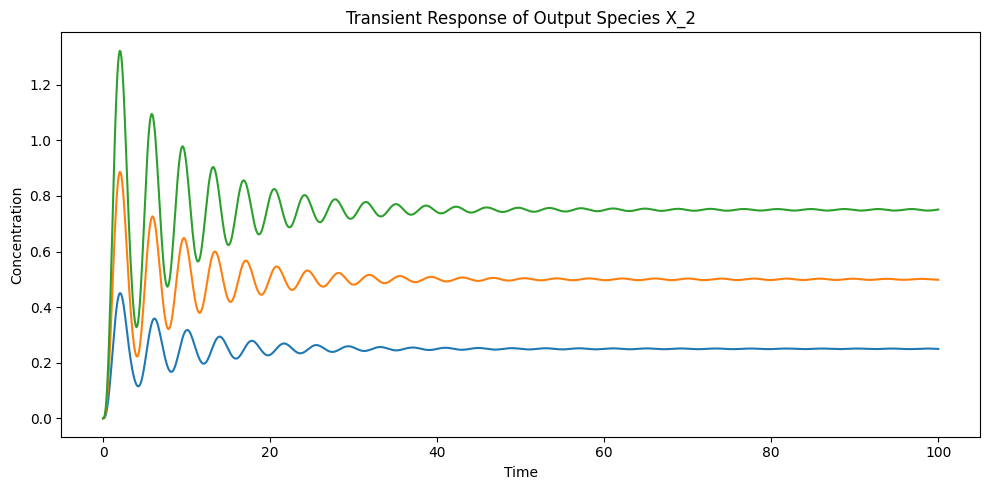

In [7]:
# Simulate Dynamics
time_horizon = np.linspace(0, 100.0, 1000, dtype=np.float32)
t, x_list, y_list, task_info = iocrn.transient_response(u_list, x0_list, time_horizon)

# Plot using class method
fig, ax = iocrn.plot_transient_response(alpha = 1)

In [8]:
# Construct the weights for the performance metric
N_t = 1000
w = np.zeros(N_t)
w[(len(w)//5)*4:] = w[(len(w)//5)*4:] + 1
w[:(len(w)//5)] = w[:(len(w)//5)]*0
w = w[np.newaxis, :]

# Compute Reward
def compute_reward(state):
   r_list = [np.array([u[0]]) for u in u_list]
   print(r_list)
   x0_list = ic.get_ic(state)
   out = dynamic_tracking_error(state, u_list, x0_list, time_horizon, r_list, w, norm=1, LARGE_NUMBER=1e4)
   return out

print(compute_reward(iocrn))

[array([0.5]), array([1.]), array([1.5])]
(np.float64(0.09999580385305747), {'type': 'transient response', 'inputs': [array([0.5]), array([1.]), array([1.5])], 'initial conditions': [array([0, 0, 0, 0])], 'time_horizon': array([  0.       ,   0.1001001,   0.2002002,   0.3003003,   0.4004004,
         0.5005005,   0.6006006,   0.7007007,   0.8008008,   0.9009009,
         1.001001 ,   1.1011012,   1.2012012,   1.3013014,   1.4014014,
         1.5015016,   1.6016016,   1.7017018,   1.8018018,   1.901902 ,
         2.002002 ,   2.102102 ,   2.2022023,   2.3023024,   2.4024024,
         2.5025024,   2.6026027,   2.7027028,   2.8028028,   2.9029028,
         3.0030031,   3.1031032,   3.2032032,   3.3033032,   3.4034035,
         3.5035036,   3.6036036,   3.7037036,   3.803804 ,   3.903904 ,
         4.004004 ,   4.104104 ,   4.204204 ,   4.304304 ,   4.4044046,
         4.5045047,   4.6046047,   4.7047048,   4.804805 ,   4.904905 ,
         5.005005 ,   5.105105 ,   5.2052054,   5.3053055, 

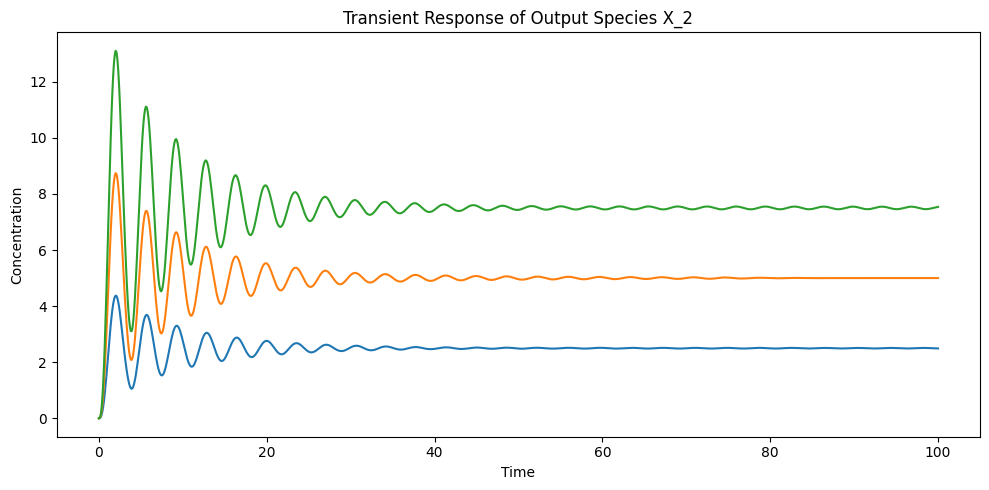

In [ ]:
iocrn.reactions[0].set_parameters([10.0])
t, x_list, y_list, task_info = iocrn.transient_response(u_list, x0_list, time_horizon)
fig, ax = iocrn.plot_transient_response(alpha = 1)
